**1. Import Library & Setup Tampilan Grafik**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Styling visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

#Warna yang digunakan
PRIMARY_COLOR = '#2B5C8F'
ACCENT_COLOR = '#E27D60'
SUCCESS_COLOR = '#41B3A3'
DANGER_COLOR = '#C34A47'

print("Libraries imported sucessfully!")

Libraries imported sucessfully!


**2. Load Dataset Gayanara: Toko Fashion Online**

In [4]:
#Load kelima dataset
products = pd.read_csv('products.csv')
reviews = pd.read_csv('reviews.csv')
customers = pd.read_csv('customers.csv')
order_items = pd.read_csv('order_items.csv')
orders = pd.read_csv('orders.csv')

print(f"Products: {products.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Orders: {orders.shape}")

Products: (300, 9)
Reviews: (1500, 8)
Customers: (800, 9)
Order Items: (4986, 6)
Orders: (3000, 12)


**3. Data Cleaning & Type Conversion**

In [9]:
# 1. Konversi format tanggal
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

# 2. Ekstrak periode Tahun-Bulan untuk analisis tren
orders['year_month'] = orders['order_date'].dt.to_period('M')

# 3. Missing value diskon & promo
orders['discount_amount_idr'] = orders['discount_amount_idr'].fillna(0)
orders['promo_code'] = orders['promo_code'].fillna('NO_PROMO')

# standardization
products['category'] = products['category'].str.capitalize()

print("Data cleaning completed!")

Data cleaning completed!


**Analisis 1: Financial Health & Reveneu Leakage**

Berapa total nilai pesanan (GMV), berapa uang riil yang masuk (Net Revenue), dan berapa kerugian akibat pembatalan/retur?

--- RINGKASAN FINANSIAL ---
Gross Merchandise Value (GMV): Rp 1,494,503,946
Net Revenue (Delivered + Shipped): Rp 1,112,869,258 (74.5%)
Revenue Leakage (Cancelled + Returned): Rp 229,163,567 (15.3%)


/tmp/ipykernel_3128/3569233322.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


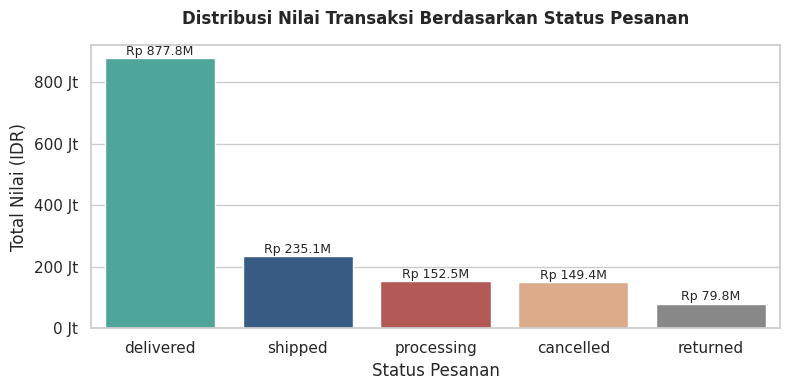

In [36]:
# Definisi status sukses vs leakage
status_summary = orders.groupby('order_status').agg(
    total_orders=('order_id', 'count'),
    total_value=('total_amount_idr', 'sum')
).reset_index()

status_summary['percentage_value'] = (status_summary['total_value'] / status_summary['total_value'].sum()) * 100

# Hitung Metrik utama
gmv = orders['total_amount_idr'].sum()
net_revenue = orders[orders['order_status'].isin(['delivered', 'shipped'])]['total_amount_idr'].sum()
leakage = orders[orders['order_status'].isin(['cancelled', 'returned'])]['total_amount_idr'].sum()

print(f"--- RINGKASAN FINANSIAL ---")
print(f"Gross Merchandise Value (GMV): Rp {gmv:,.0f}")
print(f"Net Revenue (Delivered + Shipped): Rp {net_revenue:,.0f} ({(net_revenue/gmv)*100:.1f}%)")
print(f"Revenue Leakage (Cancelled + Returned): Rp {leakage:,.0f} ({(leakage/gmv)*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=status_summary.sort_values(by='total_value', ascending=False),
    x='order_status', y='total_value',
    palette=[SUCCESS_COLOR, PRIMARY_COLOR, DANGER_COLOR, '#E8A87C', '#888888']
)
plt.title('Distribusi Nilai Transaksi Berdasarkan Status Pesanan', weight='bold', pad=15)
plt.xlabel('Status Pesanan')
plt.ylabel('Total Nilai (IDR)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x/1e6)} Jt"))
for p in ax.patches:
    ax.annotate(f"Rp {p.get_height()/1e6:.1f}M", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

**Analisis 2: Identifikasi Akar Masalah Pesanan **

Mengapa tingkat pembatalan (cancelled) terjadi? Apakah kurir atau metode bayar tertentu bermasalah?

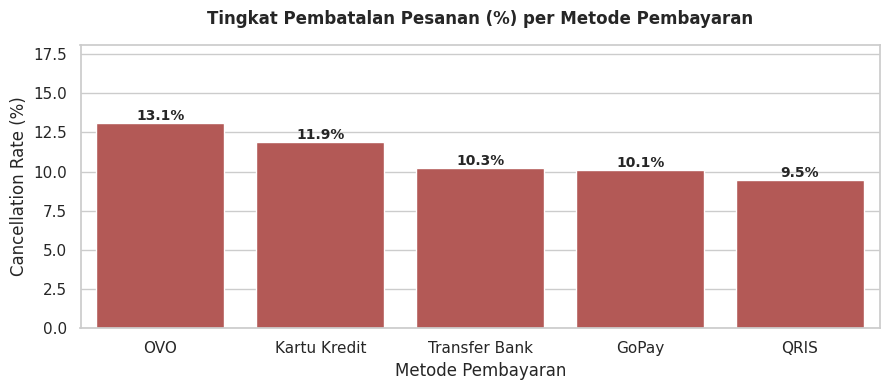

In [35]:
# Cancellation Rate per Metode Pembayaran
payment_cancellation = orders.groupby('payment_method').agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('order_status', lambda x: (x == 'cancelled').sum())
).reset_index()

payment_cancellation['cancellation_rate'] = (payment_cancellation['cancelled_orders'] / payment_cancellation['total_orders']) * 100
payment_cancellation = payment_cancellation.sort_values(by='cancellation_rate', ascending=False)

#Visualisasi
plt.figure(figsize=(9, 4))
ax = sns.barplot(data=payment_cancellation, x='payment_method', y='cancellation_rate', color=DANGER_COLOR)
plt.title('Tingkat Pembatalan Pesanan (%) per Metode Pembayaran', weight="bold", pad=15)
plt.xlabel('Metode Pembayaran')
plt.ylabel('Cancellation Rate (%)')
for p in ax.patches:
  ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')
plt.ylim(0, max(payment_cancellation['cancellation_rate']) + 5)
plt.tight_layout()
plt.show()

**Analisi 3: Performa Kategori & Evaluasi Stok Gudang **

Kategori mana yang paling menguntungkan? Apakah ada produk laris yang stoknya kosong (kehilangan potensi penjualan)?

/tmp/ipykernel_3128/300423226.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=category_perf, x='total_revenue', y='category', palette='Blues_r')


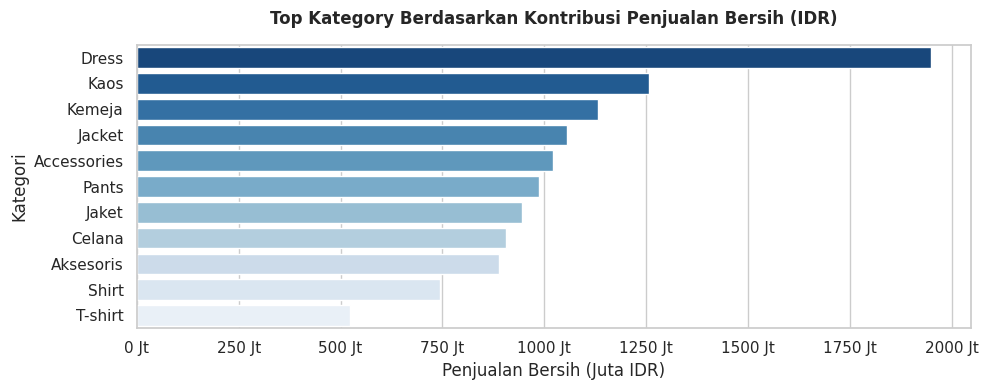


--- PRODUK POTENSIAL YANG STOKNYA KOSONG (RESTOCK SEGERA) ---
                                name          brand  total_qty  stock  \
0          Dress Bodycon Pesona Indo    Pesona Indo         21      0   
194         Kemeja Casual Senja Wear     Senja Wear         19      0   
289  Dress Mini Casual Riang Apparel  Riang Apparel         18      0   
62            Dress A-Line NusaBrand      NusaBrand         16      0   
122  Dress Mini Casual Riang Apparel  Riang Apparel         14      0   

      revenue  
0    12579000  
194   2831000  
289   5022000  
62    1424000  
122   1246000  


In [56]:
# Merge order_items + products + orders
valid_orders = orders[orders['order_status'].isin(['delivered', 'shipped'])]
items_merged = order_items.merge(valid_orders[['order_id']], on='order_id', how='inner')
items_merged = items_merged.merge(products, on='product_id', how='left')

# Kategori terlaris berdasarkan Revenue
category_perf = items_merged.groupby('category').agg(
    total_revenue=('subtotal_idr', 'sum'),
    units_sold=('quantity', 'sum')
).sort_values(by='total_revenue', ascending=False).reset_index()

# Visualisasi
plt.figure(figsize=(10,4))
ax = sns.barplot(data=category_perf, x='total_revenue', y='category', palette='Blues_r')
plt.title('Top Kategory Berdasarkan Kontribusi Penjualan Bersih (IDR)', weight='bold', pad=15)
plt.xlabel('Penjualan Bersih (Juta IDR)')
plt.ylabel('Kategori')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x/1e5)} Jt"))
plt.tight_layout()
plt.show()

# Cek produk laris yang Stoknya 0 (Stockout Risk)
top_products = items_merged.groupby(['product_id', 'name', 'brand', 'stock']).agg(
    total_qty=('quantity', 'sum'),
    revenue=('subtotal_idr', 'sum')
).reset_index().sort_values(by='total_qty', ascending=False)

stockout_heros = top_products[top_products['stock'] == 0].head(5)
print("\n--- PRODUK POTENSIAL YANG STOKNYA KOSONG (RESTOCK SEGERA) ---")
print(stockout_heros[['name', 'brand', 'total_qty', 'stock', 'revenue']])

**Analisis 4: Efektivitas Promo & Demografi Pelanggan**

Apakah kode promo benar-benar menaikkan rata-rata belanja (AOV) atau hanya memotong profit? Siapa target pasar kita?

--- ANALISIS NILAI KERANJANG BELANJA (AOV) ---
      is_promo  order_count            aov  avg_discount
0  Pakai Promo          717  470757.390516  30941.354254
1  Tanpa Promo         1059  510121.813031      0.000000


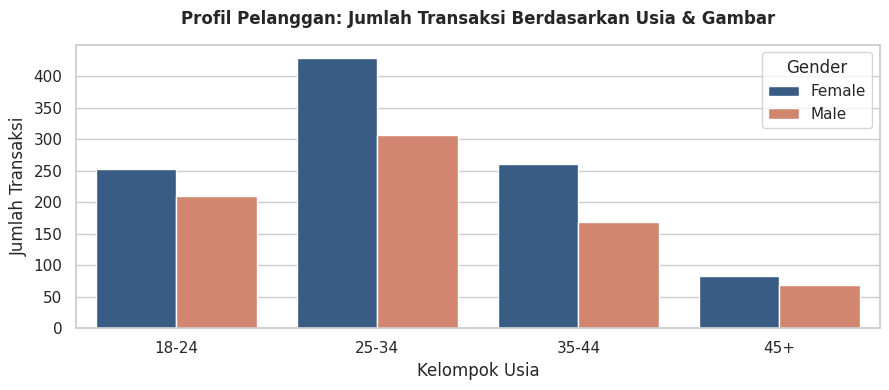

In [71]:
# Analisis Average Order Value (AOV) dari Promo vs Non-Promo
orders['is_promo'] = orders['promo_code'].apply(lambda x: 'Pakai Promo' if x != 'NO_PROMO' else 'Tanpa Promo')

delivered_orders = orders[orders['order_status'] == 'delivered']
aov_analysis = delivered_orders.groupby('is_promo').agg(
    order_count=('order_id', 'count'),
    aov=('total_amount_idr', 'mean'),
    avg_discount=('discount_amount_idr', 'mean')
).reset_index()

print("--- ANALISIS NILAI KERANJANG BELANJA (AOV) ---")
print(aov_analysis)

# Demografi Pelanggan
cust_orders = delivered_orders.merge(customers, on='customer_id', how='left')
demographic_df = cust_orders.groupby(['age_group', 'gender'])['order_id'].count().reset_index()

# Visualisasi
plt.figure(figsize=(9, 4))
sns.barplot(data=demographic_df, x='age_group', y='order_id', hue='gender', palette=[PRIMARY_COLOR, ACCENT_COLOR])
plt.title('Profil Pelanggan: Jumlah Transaksi Berdasarkan Usia & Gambar', weight='bold', pad=15)
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah Transaksi')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()